In [1]:
import sys, os, warnings, glob
warnings.filterwarnings('ignore')

current_dir = os.getcwd()
project_root = os.path.dirname(current_dir)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

from scripts.model.doNET import GATWithTransformerFusion, compute_graph_statistics_fast
from scripts.data_provider.graph_data_builder import build_pyg_data
from scripts.data_provider.data_preprocessing import clr_normalize

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch : {torch.__version__}')
print(f'Device  : {device}')

PyTorch : 2.5.1+cu121
Device  : cuda


In [29]:
import re

base_path = "/projects/vanaja_lab/satya/Datasets/GSE220474"

rna_files   = glob.glob(os.path.join(base_path, "*_RNA_counts.csv.gz"))
sample_tags = sorted(set(f.split('_')[1] for f in [os.path.basename(x) for x in rna_files]))

rna_list, adt_list = [], []
for tag in sample_tags:
    print(f"Loading {tag}...")
    rna_path    = glob.glob(os.path.join(base_path, f"*_{tag}_RNA_counts.csv.gz"))[0]
    adt_path    = glob.glob(os.path.join(base_path, f"*_{tag}_ADT_counts.csv.gz"))[0]
    assign_path = glob.glob(os.path.join(base_path, f"*_{tag}_cell_sample_assign.csv.gz"))[0]

    meta_df = pd.read_csv(assign_path, index_col=0)

    rna_df = pd.read_csv(rna_path, index_col=0).T
    adt_df = pd.read_csv(adt_path, index_col=0).T

    adata_rna = ad.AnnData(rna_df)
    adata_rna.obs = meta_df.reindex(adata_rna.obs_names)
    adata_rna.obs['batch'] = tag
    adata_rna.var_names_make_unique()

    adata_adt = ad.AnnData(adt_df)
    adata_adt.obs = meta_df.reindex(adata_adt.obs_names)
    adata_adt.obs['batch'] = tag
    adata_adt.var_names_make_unique()

    rna_list.append(adata_rna)
    adt_list.append(adata_adt)

final_rna = ad.concat(rna_list, label='sample_batch', keys=sample_tags, join='inner')
final_adt = ad.concat(adt_list, label='sample_batch', keys=sample_tags, join='inner')
final_rna.obs_names_make_unique()
final_adt.obs_names_make_unique()

# ── Clean ADT feature names: strip trailing .N clone suffix ──────────────────
def _strip_clone_suffix(name):
    cleaned = re.sub(r'\.\d+$', '', name)
    return cleaned if cleaned else name   # guard against '.10' → ''

raw_names     = list(final_adt.var_names)
cleaned_names = [_strip_clone_suffix(n) for n in raw_names]
final_adt.var_names = cleaned_names
final_adt.var_names_make_unique()        # PTPRC.1/.2/.3 → PTPRC, PTPRC-1, PTPRC-2

changed = [(r, c) for r, c in zip(raw_names, final_adt.var_names) if r != c]
print(f"Renamed {len(changed)} ADT features (e.g. {changed[:3]})")

print(f"\nRNA : {final_rna.n_obs:,} cells x {final_rna.n_vars:,} genes")
print(f"ADT : {final_adt.n_obs:,} cells x {final_adt.n_vars:,} proteins")
print(f"ADT proteins: {list(final_adt.var_names)}")

Loading CITE1...
Loading CITE2...
Loading CITE3...
Loading CITE4...
Loading CITE5...
Loading CITE6...
Loading CITE7...
Loading CITE8...
Loading CITE9...
Renamed 137 ADT features (e.g. [('CD86.1', 'CD86'), ('CD274.1', 'CD274'), ('TNFRSF14.1', 'TNFRSF14')])

RNA : 43,179 cells x 36,601 genes
ADT : 43,179 cells x 138 proteins
ADT proteins: ['CD86', 'CD274', 'TNFRSF14', 'PVR', 'NECTIN2', 'CD47', 'CD48', 'CD40', 'CD40LG', 'CD52', 'CD3D', 'CD8A', 'NCAM1', 'CD19', 'CD33', 'ITGAX', 'HLA-A', 'PTPRC', 'IL3RA', 'CD7', 'ENG', 'ITGA6', 'CCR4', 'CD4', 'CD44', 'CD14', 'FCGR3A', 'IL2RA', 'PTPRC-1', 'PDCD1', 'TIGIT', 'isotype', 'isotype-1', 'isotype-2', 'isotype-3', 'MS4A1', 'NCR1', 'PECAM1', 'MCAM', 'IGHM', 'CD5', 'CXCR3', 'CCR5', 'FCGR2A', 'CCR6', 'CXCR5', 'ITGAE', 'CD69', 'SELL', 'KLRB1', 'CTLA4', 'LAG3', 'KLRG1', 'CD27', 'LAMP1', 'FAS', 'TNFRSF4', 'HLA-DRA', 'CD1C', 'ITGAM', 'FCGR1A', 'THBD', 'CD1D', 'KLRK1', 'CR1', 'B3GAT1', 'BTLA', 'ICOS', 'CD58', 'ENTPD1', 'CX3CR1', 'CD24', 'CR2', 'ITGAL', 'CD79

In [30]:
checkpoint = torch.load("deepomapnet_model.pt", map_location=device)
sd = checkpoint["model_state_dict"]

in_channels  = sd["gat_rna1.lin.weight"].shape[1]
hidden_ch    = sd["final_proj.0.weight"].shape[0]
num_layers   = len({k.split('.')[2] for k in sd
                    if k.startswith("transformer_fusion.rna_norms.")}) or 2
has_celltypes  = any(k.startswith("celltype_head") for k in sd)
num_cell_types = sd["celltype_head.4.weight"].shape[0] if has_celltypes else None

print(f"Pretrained  in_channels={in_channels}  hidden={hidden_ch}  "
      f"layers={num_layers}  cell_types={num_cell_types}")
print(f"Pretrained out_channels (training ADT): {sd['final_proj.4.weight'].shape[0]}")
print(f"Target     out_channels (this dataset): {final_adt.n_vars}")

Pretrained  in_channels=2000  hidden=64  layers=3  cell_types=54
Pretrained out_channels (training ADT): 279
Target     out_channels (this dataset): 138


In [31]:
rna = final_rna.copy()
sc.pp.normalize_total(rna, target_sum=1e4)
sc.pp.log1p(rna)
sc.pp.highly_variable_genes(rna, n_top_genes=in_channels, flavor='seurat_v3', span=1.0)
rna_hvg = rna[:, rna.var['highly_variable']].copy()

X = rna_hvg.X.toarray() if hasattr(rna_hvg.X, 'toarray') else rna_hvg.X.copy()
X = (X - X.mean(axis=0, keepdims=True)) / (X.std(axis=0, keepdims=True) + 1e-8)
rna_hvg.X = X
print(f"RNA HVG: {rna_hvg.shape}  (z-scored)")

AttributeError: 'PathCollection' object has no attribute 'pp'

In [ ]:
import scipy.sparse as sp

adt = final_adt.copy()
adt.X = adt.X.astype(float)

# CLR normalize
X_adt = adt.X.toarray() if sp.issparse(adt.X) else np.array(adt.X)
log1p_adt = np.log1p(X_adt)
clr_adt   = log1p_adt - log1p_adt.mean(axis=1, keepdims=True)
adt.X = clr_adt.astype(np.float32)

# Compute per-protein mean/std for denormalization later
adt_mean = clr_adt.mean(axis=0)   # (n_proteins,)
adt_std  = clr_adt.std(axis=0) + 1e-8

# Z-score for training stability
adt.X = ((clr_adt - adt_mean) / adt_std).astype(np.float32)

print(f"ADT CLR + z-scored: {adt.shape}")
print(f"ADT mean range : [{adt_mean.min():.3f}, {adt_mean.max():.3f}]")
print(f"ADT std  range : [{adt_std.min():.3f},  {adt_std.max():.3f}]")

In [ ]:
# Adjust the column name and logic to match your dataset's metadata
_aml_col = 'aml'   # change if your column is named differently

if _aml_col in final_rna.obs.columns:
    _raw = final_rna.obs[_aml_col].values
    if np.issubdtype(type(_raw[0]), np.integer) or np.issubdtype(type(_raw[0]), np.floating):
        aml_labels = _raw.astype(int)
    else:
        _non_aml = {'control', '0', 'normal', 'false', 'no'}
        aml_labels = np.array([0 if str(v).strip().lower() in _non_aml else 1
                               for v in _raw], dtype=int)
    print(f"AML labels — Normal: {(aml_labels==0).sum():,}  AML: {(aml_labels==1).sum():,}")
else:
    print(f"Column '{_aml_col}' not found. Using all-Normal labels.")
    print(f"Available obs columns: {list(final_rna.obs.columns)}")
    aml_labels = np.zeros(final_rna.n_obs, dtype=int)

In [32]:
n_cells = final_rna.n_obs
indices = np.arange(n_cells)

idx_train, idx_temp = train_test_split(
    indices, test_size=0.30, random_state=42, stratify=aml_labels
)
idx_val, idx_test = train_test_split(
    idx_temp, test_size=0.50, random_state=42, stratify=aml_labels[idx_temp]
)

print(f"Train: {len(idx_train):,}  Val: {len(idx_val):,}  Test: {len(idx_test):,}")

Train: 30,225  Val: 6,477  Test: 6,477


In [33]:
def build_split_graph(rna_obj, adt_obj, idx):
    rna_sub = rna_obj[idx].copy()
    adt_sub = adt_obj[idx].copy()
    rna_pyg = build_pyg_data(rna_sub, use_pca=False)
    adt_pyg = build_pyg_data(adt_sub, use_pca=True)
    num_nodes = rna_pyg.num_nodes
    nd_rna, cc_rna = compute_graph_statistics_fast(rna_pyg.edge_index, num_nodes)
    nd_adt, cc_adt = compute_graph_statistics_fast(adt_pyg.edge_index, num_nodes)
    return rna_pyg, adt_pyg, nd_rna, cc_rna, nd_adt, cc_adt

print("Building train graph...")
train_rna_pyg, train_adt_pyg, train_nd_rna, train_cc_rna, train_nd_adt, train_cc_adt = \
    build_split_graph(rna_hvg, adt, idx_train)

print("Building val graph...")
val_rna_pyg, val_adt_pyg, val_nd_rna, val_cc_rna, val_nd_adt, val_cc_adt = \
    build_split_graph(rna_hvg, adt, idx_val)

print("Building test graph...")
test_rna_pyg, test_adt_pyg, test_nd_rna, test_cc_rna, test_nd_adt, test_cc_adt = \
    build_split_graph(rna_hvg, adt, idx_test)

# ADT targets (z-scored CLR)
adt_X = adt.X.toarray() if sp.issparse(adt.X) else np.array(adt.X)
train_adt_targets = torch.tensor(adt_X[idx_train], dtype=torch.float32)
val_adt_targets   = torch.tensor(adt_X[idx_val],   dtype=torch.float32)
test_adt_targets  = torch.tensor(adt_X[idx_test],  dtype=torch.float32)

train_aml = torch.tensor(aml_labels[idx_train], dtype=torch.float32)
val_aml   = torch.tensor(aml_labels[idx_val],   dtype=torch.float32)

print(f"\nTrain graph — nodes: {train_rna_pyg.num_nodes:,}  edges: {train_rna_pyg.num_edges:,}")
print(f"Val   graph — nodes: {val_rna_pyg.num_nodes:,}  edges: {val_rna_pyg.num_edges:,}")
print(f"Test  graph — nodes: {test_rna_pyg.num_nodes:,}  edges: {test_rna_pyg.num_edges:,}")

Building train graph...
build_pyg_data called with use_pca=False, use_rep=None
Input adata shape: (30225, 2000)
Computing neighbor graph using rep: raw X
Computing leiden clusters...
Using raw features, shape: (30225, 2000)
build_pyg_data called with use_pca=True, use_rep=None
Input adata shape: (30225, 138)
Computing PCA with 50 components...
PCA computed, shape: (30225, 50)
Computing neighbor graph using rep: X_pca
Computing leiden clusters...
Using X_pca for node features, shape: (30225, 50)
Building val graph...
build_pyg_data called with use_pca=False, use_rep=None
Input adata shape: (6477, 2000)
Computing neighbor graph using rep: raw X
Computing leiden clusters...
Using raw features, shape: (6477, 2000)
build_pyg_data called with use_pca=True, use_rep=None
Input adata shape: (6477, 138)
Computing PCA with 50 components...
PCA computed, shape: (6477, 50)
Computing neighbor graph using rep: X_pca
Computing leiden clusters...
Using X_pca for node features, shape: (6477, 50)
Buildin

In [34]:
n_target_proteins = final_adt.n_vars

# Build model with original out_channels — we replace final_proj below
model = GATWithTransformerFusion(
    in_channels=in_channels,
    hidden_channels=hidden_ch,
    out_channels=sd['final_proj.4.weight'].shape[0],  # pretrained dim
    heads=4,
    dropout=0.1,
    nhead=4,
    num_layers=num_layers,
    use_adapters=True,
    use_positional_encoding=True,
    use_sparse_attention=True,
    num_cell_types=num_cell_types,
).to(device)

model.load_state_dict(sd)
print("Pretrained weights loaded.")

# ── Replace final_proj to match target protein count ──────────────────────────
model.final_proj = nn.Sequential(
    nn.Linear(hidden_ch, hidden_ch),
    nn.LayerNorm(hidden_ch),
    nn.GELU(),
    nn.Dropout(0.1),
    nn.Linear(hidden_ch, n_target_proteins),
).to(device)
for m in model.final_proj:
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        nn.init.zeros_(m.bias)

# ── Warm-start final output layer from matched pretrained proteins ─────────────
pretrained_names = checkpoint.get('adt_names', [])
if pretrained_names:
    pretrain_idx = {n: j for j, n in enumerate(pretrained_names)}
    pre_w = sd['final_proj.4.weight']   # (279, hidden_ch)
    pre_b = sd['final_proj.4.bias']     # (279,)
    new_w = model.final_proj[4].weight.data
    new_b = model.final_proj[4].bias.data
    matched, skipped = [], []
    for i, tgt in enumerate(final_adt.var_names):
        if tgt in pretrain_idx:
            j = pretrain_idx[tgt]
            new_w[i] = pre_w[j]
            new_b[i] = pre_b[j]
            matched.append(tgt)
        else:
            skipped.append(tgt)
    model.final_proj[4].weight.data.copy_(new_w)
    model.final_proj[4].bias.data.copy_(new_b)
    print(f"Warm-started {len(matched)}/{n_target_proteins} output rows from pretrained weights")
    print(f"Xavier-init  {len(skipped)} rows (novel / isotypes): {skipped[:5]}{'...' if len(skipped)>5 else ''}")
else:
    print("No 'adt_names' in checkpoint — all rows Xavier-init (re-run with new checkpoint to warm-start)")

# ── Freeze backbone — keep adapters + new heads trainable ─────────────────────
frozen_modules = [
    'gat_rna1', 'gat_rna2', 'gat_adt_init', 'gat_adt',
    'batch_norm_rna', 'batch_norm_adt',
    'transformer_fusion.rna_proj', 'transformer_fusion.adt_proj',
    'transformer_fusion.cross_attention_layers',
    'transformer_fusion.rna_norms', 'transformer_fusion.adt_norms',
]

for name, param in model.named_parameters():
    frozen = any(name.startswith(m) for m in frozen_modules)
    param.requires_grad = not frozen

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"\nTrainable params : {trainable:,} / {total:,}  ({100*trainable/total:.1f}%)")

Pretrained weights loaded.
Warm-started 26/138 output rows from pretrained weights
Xavier-init  112 rows (novel / isotypes): ['CD274', 'TNFRSF14', 'PVR', 'NECTIN2', 'CD40LG']...

Trainable params : 134,356 / 733,076  (18.3%)


In [35]:
EPOCHS           = 500
LR               = 5e-4
ADT_WEIGHT       = 1.0
AML_WEIGHT       = 0.3
PATIENCE         = 10

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

def forward_pass(rna_pyg, adt_pyg, nd_rna, cc_rna, nd_adt, cc_adt):
    return model(
        x=rna_pyg.x.to(device),
        edge_index_rna=rna_pyg.edge_index.to(device),
        edge_index_adt=adt_pyg.edge_index.to(device),
        node_degrees_rna=nd_rna.to(device),
        node_degrees_adt=nd_adt.to(device),
        clustering_coeffs_rna=cc_rna.to(device),
        clustering_coeffs_adt=cc_adt.to(device),
    )

history = {'train_loss': [], 'val_loss': [], 'val_r2': []}
best_val_loss = float('inf')
patience_counter = 0
best_state = None

for epoch in range(1, EPOCHS + 1):
    # ── Train ──
    model.train()
    optimizer.zero_grad()

    adt_pred, aml_pred, _ = forward_pass(
        train_rna_pyg, train_adt_pyg,
        train_nd_rna, train_cc_rna, train_nd_adt, train_cc_adt
    )

    adt_loss = F.mse_loss(adt_pred, train_adt_targets.to(device))
    aml_loss = F.binary_cross_entropy_with_logits(
        aml_pred.squeeze(), train_aml.to(device)
    )
    reg_loss = model.get_regularization_loss() if hasattr(model, 'get_regularization_loss') else 0.0
    loss = ADT_WEIGHT * adt_loss + AML_WEIGHT * aml_loss + reg_loss

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    scheduler.step()

    # ── Validate ──
    model.eval()
    with torch.no_grad():
        val_adt_pred, val_aml_pred, _ = forward_pass(
            val_rna_pyg, val_adt_pyg,
            val_nd_rna, val_cc_rna, val_nd_adt, val_cc_adt
        )
        val_adt_loss = F.mse_loss(val_adt_pred, val_adt_targets.to(device))
        val_aml_loss = F.binary_cross_entropy_with_logits(
            val_aml_pred.squeeze(), val_aml.to(device)
        )
        val_loss = ADT_WEIGHT * val_adt_loss + AML_WEIGHT * val_aml_loss

        # R² on val set
        vp = val_adt_pred.cpu().numpy()
        vt = val_adt_targets.numpy()
        val_r2 = float(np.mean([r2_score(vt[:, i], vp[:, i])
                                 for i in range(vt.shape[1])]))

    history['train_loss'].append(loss.item())
    history['val_loss'].append(val_loss.item())
    history['val_r2'].append(val_r2)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{EPOCHS}  "
              f"train={loss.item():.4f}  val={val_loss.item():.4f}  "
              f"val_R²={val_r2:.4f}  "
              f"lr={scheduler.get_last_lr()[0]:.2e}")

    # ── Early stopping ──
    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch} (patience={PATIENCE})")
            break

model.load_state_dict(best_state)
print(f"\nBest val loss: {best_val_loss:.4f}  Best val R²: {max(history['val_r2']):.4f}")

Epoch   1/500  train=3.6932  val=1.8087  val_R²=-0.2857  lr=5.00e-04
Epoch   5/500  train=2.0791  val=1.3517  val_R²=-0.1994  lr=5.00e-04
Epoch  10/500  train=1.2332  val=1.1280  val_R²=-0.1223  lr=5.00e-04
Epoch  15/500  train=1.1049  val=1.0708  val_R²=-0.0670  lr=4.99e-04
Epoch  20/500  train=1.0558  val=1.0319  val_R²=-0.0281  lr=4.98e-04
Epoch  25/500  train=1.0276  val=1.0085  val_R²=-0.0046  lr=4.97e-04
Epoch  30/500  train=1.0098  val=0.9929  val_R²=0.0108  lr=4.96e-04
Epoch  35/500  train=0.9962  val=0.9809  val_R²=0.0228  lr=4.94e-04
Epoch  40/500  train=0.9844  val=0.9700  val_R²=0.0336  lr=4.92e-04
Epoch  45/500  train=0.9729  val=0.9586  val_R²=0.0450  lr=4.90e-04
Epoch  50/500  train=0.9607  val=0.9469  val_R²=0.0566  lr=4.88e-04
Epoch  55/500  train=0.9496  val=0.9356  val_R²=0.0680  lr=4.85e-04
Epoch  60/500  train=0.9394  val=0.9246  val_R²=0.0789  lr=4.82e-04
Epoch  65/500  train=0.9287  val=0.9142  val_R²=0.0893  lr=4.79e-04
Epoch  70/500  train=0.9185  val=0.9045  v

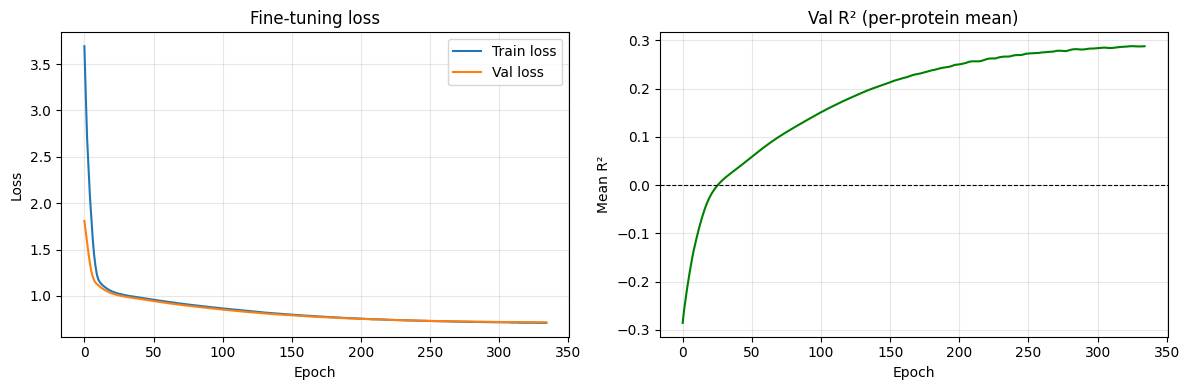

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_loss'], label='Train loss')
axes[0].plot(history['val_loss'],   label='Val loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Fine-tuning loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history['val_r2'], color='green')
axes[1].axhline(0, color='black', lw=0.8, ls='--')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Mean R²')
axes[1].set_title('Val R² (per-protein mean)'); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('finetune_curves.pdf', bbox_inches='tight', dpi=150)
plt.show()

In [38]:
import math

model.eval()
with torch.no_grad():
    test_adt_pred, test_aml_pred, test_fused = forward_pass(
        test_rna_pyg, test_adt_pyg,
        test_nd_rna, test_cc_rna, test_nd_adt, test_cc_adt
    )

adt_mean_t = torch.tensor(adt_mean, dtype=torch.float32).to(device)
adt_std_t  = torch.tensor(adt_std,  dtype=torch.float32).to(device)

# Denormalize both pred and true to CLR space
pred_clr = (test_adt_pred * adt_std_t + adt_mean_t).cpu().numpy()
true_clr = (test_adt_targets * torch.tensor(adt_std) + torch.tensor(adt_mean)).numpy()

protein_names = list(final_adt.var_names)
n_proteins    = len(protein_names)

records = []
for i, name in enumerate(protein_names):
    tv, pv     = true_clr[:, i], pred_clr[:, i]
    r, _       = pearsonr(tv, pv)
    rho, _     = spearmanr(tv, pv)
    r2         = r2_score(tv, pv)
    records.append({'protein': name, 'pearson_r': r, 'spearman_rho': rho, 'R2': r2})

metrics_df = pd.DataFrame(records).sort_values('pearson_r', ascending=False)

print(f"{'Metric':<14} {'Mean':>8} {'Median':>8} {'Min':>8} {'Max':>8}")
for col in ['pearson_r', 'spearman_rho', 'R2']:
    v = metrics_df[col]
    print(f"{col:<14} {v.mean():>8.4f} {v.median():>8.4f} {v.min():>8.4f} {v.max():>8.4f}")
print()
print(metrics_df.to_string(index=False))

Metric             Mean   Median      Min      Max
pearson_r        0.5144   0.5155   0.2003   0.8845
spearman_rho     0.4755   0.4706   0.1984   0.8346
R2               0.2904   0.2603   0.0397   0.7794

  protein  pearson_r  spearman_rho       R2
  CLEC12A   0.884486      0.830510 0.779357
      CD2   0.862396      0.805707 0.742285
      CD5   0.854915      0.751789 0.729807
     CD3D   0.852688      0.768691 0.724637
     CD48   0.842709      0.834560 0.701088
     TFRC   0.828436      0.563038 0.665470
     CD33   0.807740      0.784672 0.650501
    ITGAX   0.805423      0.736633 0.647160
     CD36   0.801621      0.736977 0.633670
    ITGB2   0.795842      0.814220 0.620854
  PTPRC-2   0.775570      0.795487 0.590667
     CD19   0.773437      0.358735 0.591388
      CR1   0.773400      0.725976 0.589205
   PECAM1   0.771756      0.759193 0.592670
      CD7   0.754242      0.753171 0.568239
    ITGAL   0.752597      0.736620 0.554609
   B3GAT1   0.750866      0.651530 0.560808
   

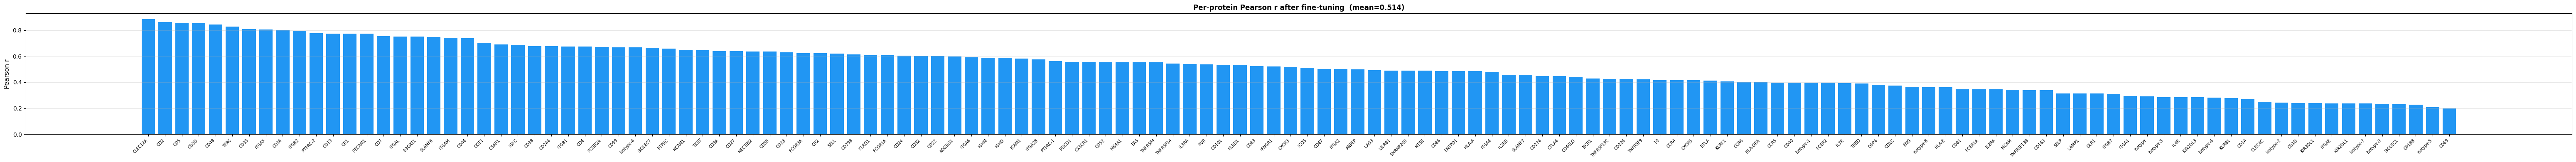

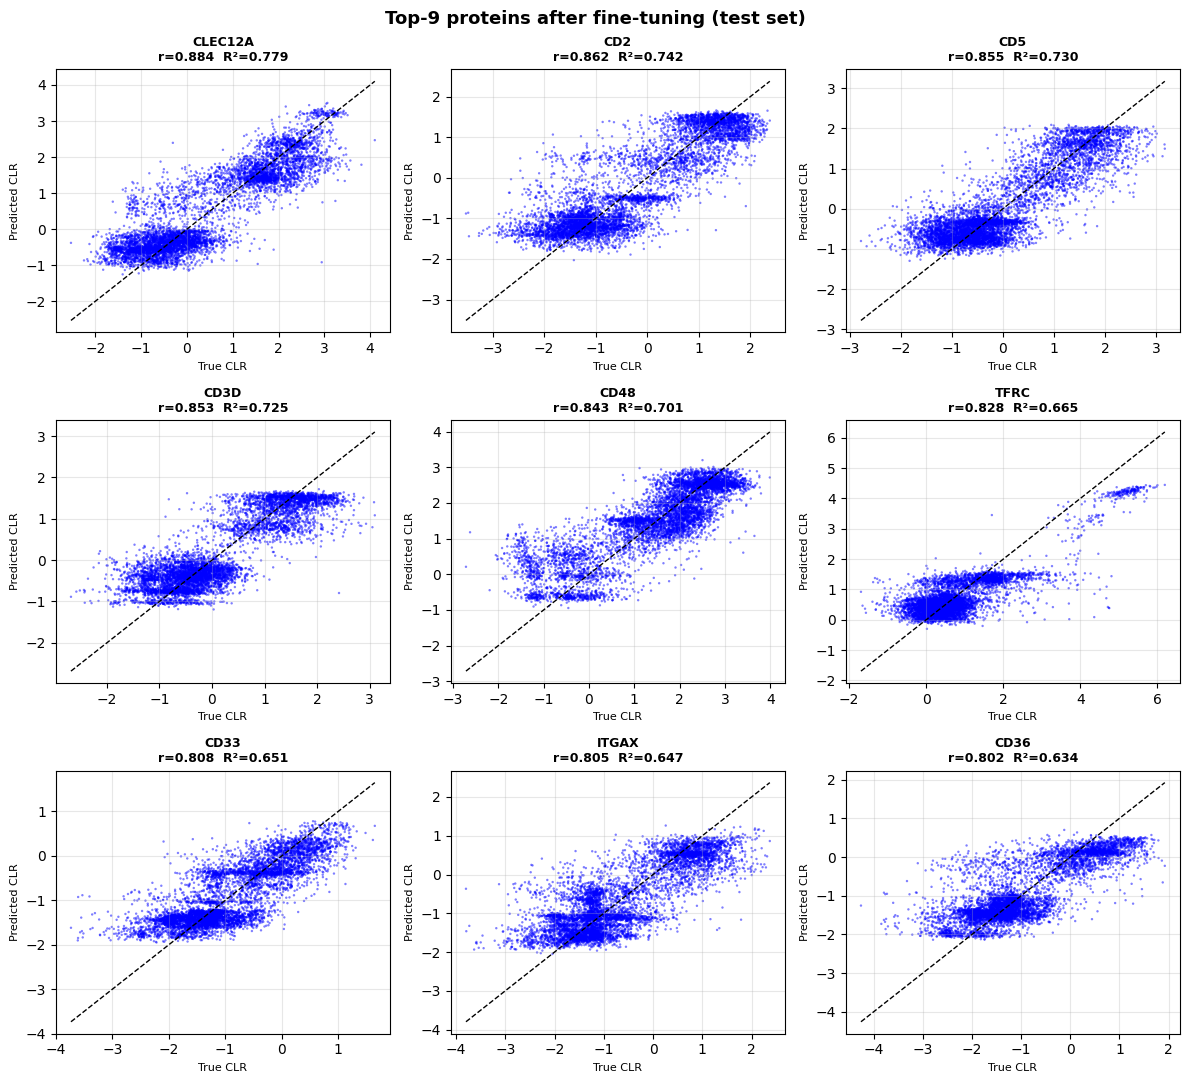

In [39]:
# Bar chart — Pearson r per protein
fig, ax = plt.subplots(figsize=(max(8, n_proteins * 0.45), 4))
colors = ['#2196F3' if r >= 0 else '#F44336' for r in metrics_df['pearson_r']]
ax.bar(metrics_df['protein'], metrics_df['pearson_r'], color=colors)
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('Pearson r', fontsize=11)
ax.set_title(f'Per-protein Pearson r after fine-tuning  '
             f'(mean={metrics_df["pearson_r"].mean():.3f})',
             fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=7)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('finetune_pearson_bar.pdf', bbox_inches='tight', dpi=150)
plt.show()

# Scatter — top-9 proteins by Pearson r
top9 = metrics_df.head(9)
ncols, nrows = 3, 3
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 11))
axes = axes.flatten()
aml_test = aml_labels[idx_test]

for rank, (_, row) in enumerate(top9.iterrows()):
    i   = protein_names.index(row['protein'])
    ax  = axes[rank]
    ax.scatter(true_clr[:, i], pred_clr[:, i],
               c=aml_test, cmap='bwr', s=3, alpha=0.5, rasterized=True, linewidths=0)
    mn = min(true_clr[:, i].min(), pred_clr[:, i].min())
    mx = max(true_clr[:, i].max(), pred_clr[:, i].max())
    ax.plot([mn, mx], [mn, mx], 'k--', lw=1)
    ax.set_title(f"{row['protein']}\nr={row['pearson_r']:.3f}  R²={row['R2']:.3f}",
                 fontsize=9, fontweight='bold')
    ax.set_xlabel('True CLR', fontsize=8)
    ax.set_ylabel('Predicted CLR', fontsize=8)
    ax.grid(alpha=0.3)

fig.suptitle('Top-9 proteins after fine-tuning (test set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('finetune_scatter_top9.pdf', bbox_inches='tight', dpi=150)
plt.show()

UMAP embedding: (6477, 2)


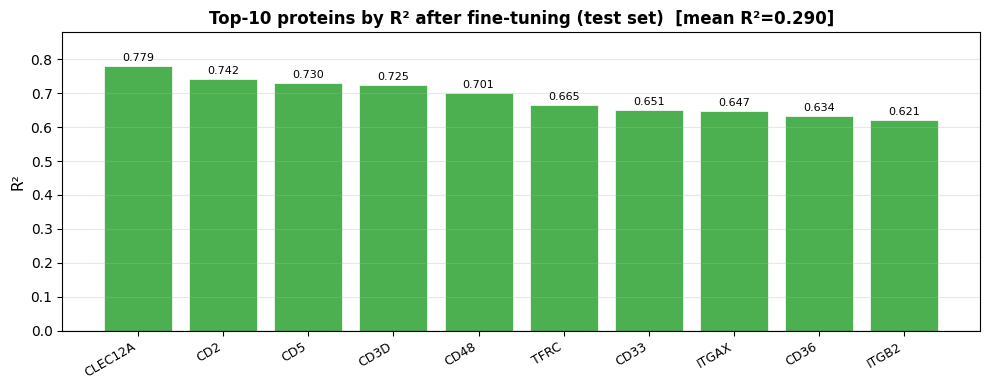

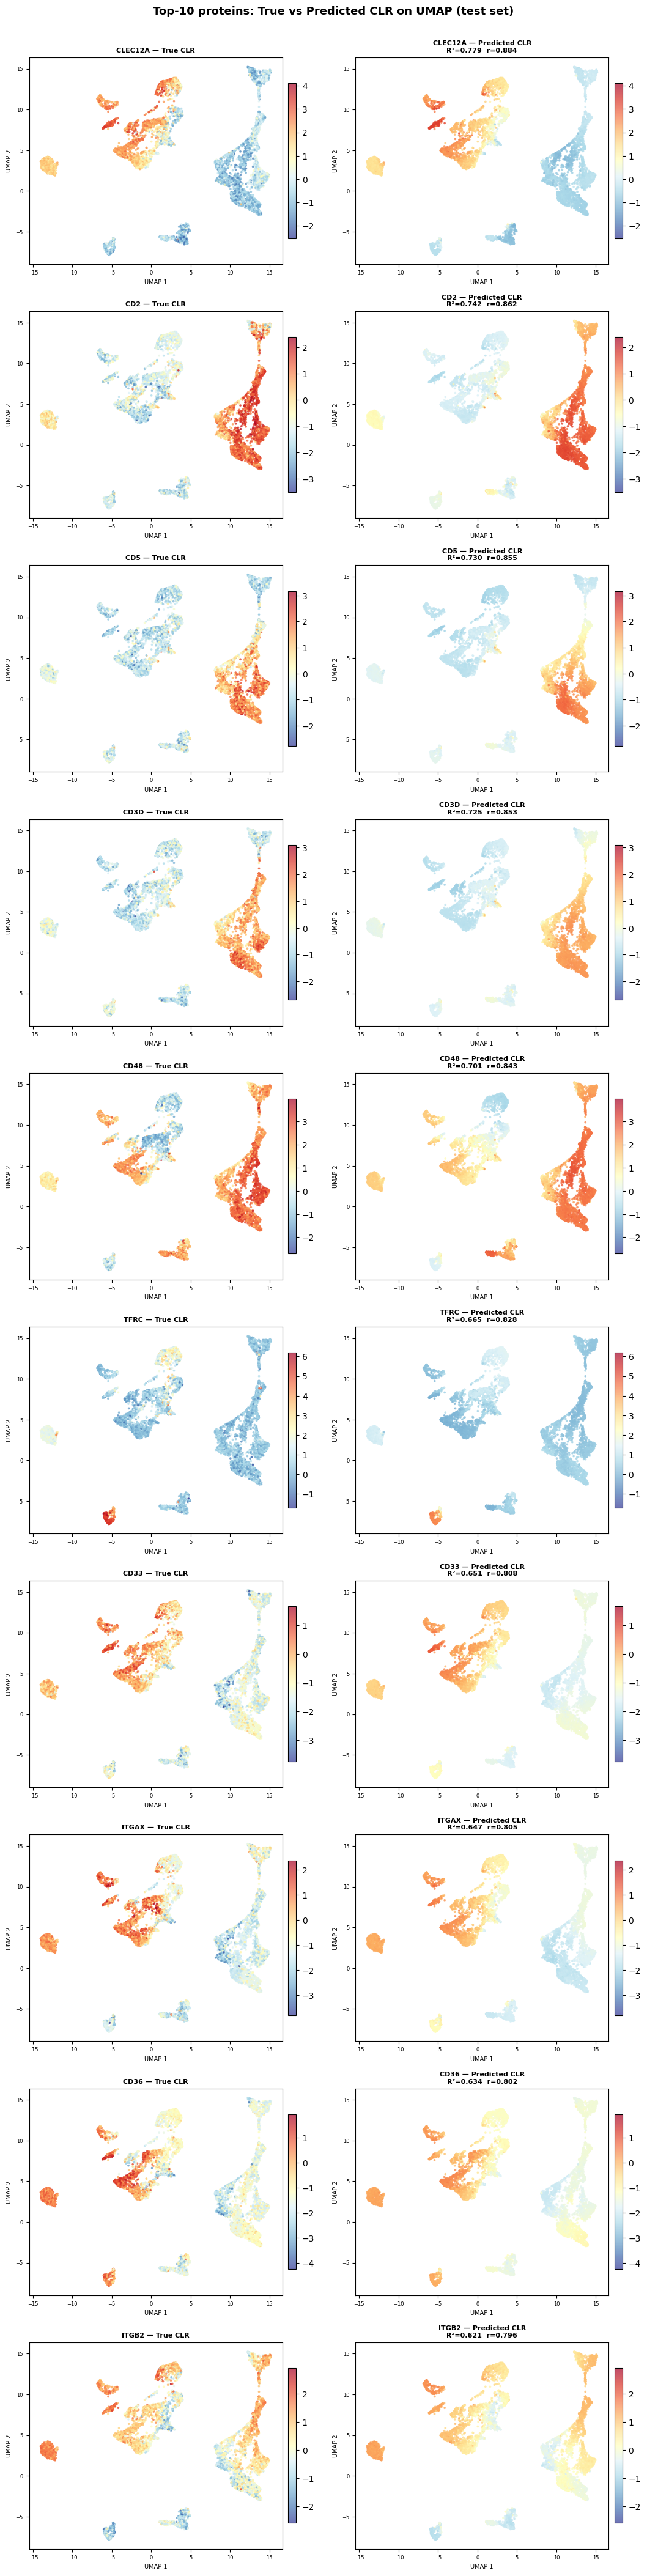

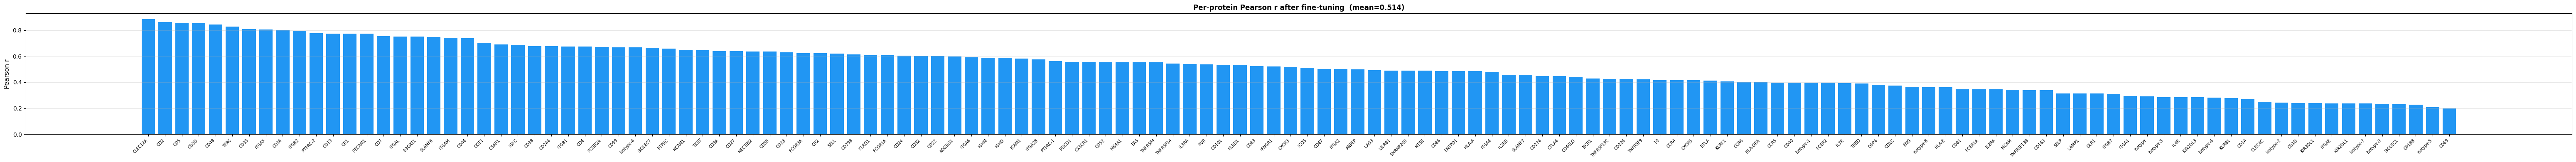

In [40]:
import umap as umap_lib

# ── Compute UMAP from fused test embeddings (computed once) ──────────────────
reducer = umap_lib.UMAP(n_components=2, random_state=42, n_neighbors=30, min_dist=0.3)
emb_2d  = reducer.fit_transform(test_fused.cpu().numpy())
print(f"UMAP embedding: {emb_2d.shape}")

top10    = metrics_df.sort_values('R2', ascending=False).head(10)
aml_test = aml_labels[idx_test]

# ── R² bar chart — top 10 ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
bar_colors = ['#4CAF50' if r2 >= 0 else '#F44336' for r2 in top10['R2']]
bars = ax.bar(top10['protein'], top10['R2'], color=bar_colors, edgecolor='white', linewidth=0.5)
ax.bar_label(bars, fmt='%.3f', fontsize=8, padding=2)
ax.axhline(0, color='black', lw=0.8)
ax.set_ylim(bottom=min(0, top10['R2'].min() - 0.05), top=top10['R2'].max() + 0.10)
ax.set_ylabel('R²', fontsize=11)
ax.set_title(f'Top-10 proteins by R² after fine-tuning (test set)  '
             f'[mean R²={metrics_df["R2"].mean():.3f}]',
             fontsize=12, fontweight='bold')
plt.xticks(rotation=30, ha='right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('finetune_r2_top10.pdf', bbox_inches='tight', dpi=150)
plt.show()

# ── UMAP True vs Predicted — top 10 proteins (10 rows × 2 cols) ──────────────
fig, axes = plt.subplots(10, 2, figsize=(11, 42))

for rank, (_, row) in enumerate(top10.iterrows()):
    i   = protein_names.index(row['protein'])
    tv  = true_clr[:, i]
    pv  = pred_clr[:, i]
    vmin, vmax = min(tv.min(), pv.min()), max(tv.max(), pv.max())

    for col_idx, (vals, label) in enumerate([(tv, 'True CLR'), (pv, 'Predicted CLR')]):
        ax = axes[rank, col_idx]
        sc = ax.scatter(
            emb_2d[:, 0], emb_2d[:, 1],
            c=vals, cmap='RdYlBu_r', s=3, alpha=0.7,
            rasterized=True, vmin=vmin, vmax=vmax,
        )
        plt.colorbar(sc, ax=ax, shrink=0.75, pad=0.02)
        title = (f'{row["protein"]} — {label}'
                 if col_idx == 0
                 else f'{row["protein"]} — {label}\nR²={row["R2"]:.3f}  r={row["pearson_r"]:.3f}')
        ax.set_title(title, fontsize=8, fontweight='bold')
        ax.set_xlabel('UMAP 1', fontsize=7)
        ax.set_ylabel('UMAP 2', fontsize=7)
        ax.tick_params(labelsize=6)

fig.suptitle('Top-10 proteins: True vs Predicted CLR on UMAP (test set)',
             fontsize=13, fontweight='bold', y=1.002)
plt.tight_layout()
plt.savefig('finetune_umap_top10.pdf', bbox_inches='tight', dpi=150)
plt.show()

# ── All-protein Pearson r bar (overview) ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(max(8, n_proteins * 0.45), 4))
all_sorted = metrics_df.sort_values('pearson_r', ascending=False)
colors_all = ['#2196F3' if r >= 0 else '#F44336' for r in all_sorted['pearson_r']]
ax.bar(all_sorted['protein'], all_sorted['pearson_r'], color=colors_all)
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('Pearson r', fontsize=11)
ax.set_title(f'Per-protein Pearson r after fine-tuning  '
             f'(mean={metrics_df["pearson_r"].mean():.3f})',
             fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=7)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('finetune_pearson_bar.pdf', bbox_inches='tight', dpi=150)
plt.show()

In [41]:
import re                                                                                                                                                
                                                                                                                                                           
def strip_suffix(name):                                                                                                                                  
    # Remove trailing .N (e.g. .1, .2, .10) — keep GGT1.2 → GGT1 etc.                                                                                    
    return re.sub(r'\.\d+$', '', name)                                                                                                                   
                                                                                                                                                           
pretrained_proteins = pretrained_ckpt.get('adt_names', [])                                                                                               
target_norm   = {strip_suffix(p): p for p in protein_names}                                                                                              
pretrain_norm = {strip_suffix(p): p for p in pretrained_proteins}                                                                                        
                  
overlap_base = set(target_norm) & set(pretrain_norm)                                                                                                     
novel_base   = set(target_norm) - set(pretrain_norm)
isotypes     = {k for k in target_norm if k.startswith('isotype')}                                                                                       
                                                                                                                                                           
print(f"Pretrained proteins (raw)  : {len(pretrained_proteins)}")
print(f"Target proteins (raw)      : {len(protein_names)}")                                                                                              
print(f"Matched after stripping    : {len(overlap_base) - len(isotypes)}")                                                                               
print(f"Isotype controls (noise)   : {len(isotypes)}")                                                                                                   
print(f"Truly novel proteins       : {len(novel_base - isotypes)}")                                                                                      
print(f"\nMatched: {sorted(overlap_base - isotypes)}")                                                                                                   
print(f"Truly novel: {sorted(novel_base - isotypes)}")

Pretrained proteins (raw)  : 279
Target proteins (raw)      : 138
Matched after stripping    : 16
Isotype controls (noise)   : 10
Truly novel proteins       : 102

Matched: ['CD14', 'CD163', 'CD19', 'CD2', 'CD22', 'CD24', 'CD27', 'CD28', 'CD33', 'CD36', 'CD38', 'CD4', 'CD40', 'CD44', 'CD47', 'CD48', 'CD5', 'CD52', 'CD69', 'CD7', 'CD82', 'CD83', 'CD86', 'CD99', 'CLEC12A', 'CX3CR1']
Truly novel: ['', 'ADGRG1', 'ANPEP', 'B3GAT1', 'BTLA', 'C5AR1', 'CCR4', 'CCR5', 'CCR6', 'CD101', 'CD1C', 'CD1D', 'CD226', 'CD244', 'CD274', 'CD3D', 'CD40LG', 'CD58', 'CD79B', 'CD81', 'CD8A', 'CLEC4C', 'CR1', 'CR2', 'CTLA4', 'CXCR3', 'CXCR5', 'DPP4', 'ENG', 'ENTPD1', 'FAS', 'FCER1A', 'FCER2', 'FCGR1A', 'FCGR2A', 'FCGR3A', 'GGT1', 'GP1BB', 'HLA-A', 'HLA-DRA', 'HLA-E', 'ICAM1', 'ICOS', 'IFNGR1', 'IGHD', 'IGHM', 'IGKC', 'IL2RA', 'IL2RB', 'IL3RA', 'IL4R', 'IL7R', 'ITGA1', 'ITGA2', 'ITGA2B', 'ITGA4', 'ITGA6', 'ITGAE', 'ITGAL', 'ITGAM', 'ITGAX', 'ITGB1', 'ITGB2', 'ITGB7', 'KIR2DL1', 'KIR2DL3', 'KIR3DL1', 'KLRB1', 'K

In [42]:
torch.save(
    {
        'model_state_dict': model.state_dict(),
        'normalization': {
            'adt_mean': torch.tensor(adt_mean, dtype=torch.float32),
            'adt_std':  torch.tensor(adt_std,  dtype=torch.float32),
        },
        'adt_names':  protein_names,
        'in_channels': in_channels,
        'hidden_channels': hidden_ch,
        'out_channels': n_target_proteins,
        'num_layers': num_layers,
        'finetune_dataset': 'GSE220474',
    },
    'deepomapnet_finetuned.pt',
)
print(f'Saved deepomapnet_finetuned.pt')
print(f'  Proteins : {n_target_proteins} — {protein_names[:5]} ...')
print(f'  Best val R² : {max(history["val_r2"]):.4f}')

Saved deepomapnet_finetuned.pt
  Proteins : 138 — ['CD86', 'CD274', 'TNFRSF14', 'PVR', 'NECTIN2'] ...
  Best val R² : 0.2881
